In [22]:
import torch
torch.backends.mps.is_available(), torch.backends.mps.is_built()

### This forces inline rendering.
%matplotlib inline


In [1]:
from ultralytics import YOLO
model = YOLO("yolov8s.pt")
model.info()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/car/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

In [2]:
from ultralytics import YOLO
import torch

# Load a pretrained YOLOv8-small model
model = YOLO("yolov8s.pt")

# Force YOLO to use MPS (Apple GPU)
device = "mps" if torch.backends.mps.is_available() else "cpu"

# Run a test prediction on an example image
results = model.predict(source="https://ultralytics.com/images/bus.jpg", device=device)

results[0].show()



image 1/1 /Users/car/CSUChico/CSCI611/yolov8/bus.jpg: 640x480 4 persons, 1 bus, 253.0ms
Speed: 31.4ms preprocess, 253.0ms inference, 375.5ms postprocess per image at shape (1, 3, 640, 480)


In [3]:
import os
import shutil
import random
from pathlib import Path

# Your actual dataset paths
source_dir = Path("/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/RealWaste")
train_dir = Path("/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset/train")
val_dir = Path("/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset/val")

# Ensure reproducibility
random.seed(42)

for class_folder in source_dir.iterdir():
    if class_folder.is_dir():
        class_name = class_folder.name
        
        # Create class folders in train and val
        (train_dir / class_name).mkdir(parents=True, exist_ok=True)
        (val_dir / class_name).mkdir(parents=True, exist_ok=True)
        
        # List all images
        images = list(class_folder.glob("*"))
        random.shuffle(images)
        
        # 80/20 split
        split_idx = int(len(images) * 0.8)
        train_images = images[:split_idx]
        val_images = images[split_idx:]
        
        # Copy files
        for img in train_images:
            shutil.copy(img, train_dir / class_name / img.name)
        for img in val_images:
            shutil.copy(img, val_dir / class_name / img.name)

print("Dataset split complete.")


Dataset split complete.


In [ ]:
yaml_content = """
path: /Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset
train: train
val: val
"""

with open("/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/realwaste.yaml", "w") as f:
    f.write(yaml_content)

print("realwaste.yaml created.")


In [5]:
from ultralytics import YOLO
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

model = YOLO("yolov8s-cls.pt")

model.train(
    data="/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset",
    epochs=30,
    imgsz=224,
    device=device,
    batch=32
)



Using device: mps
Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.11.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x332141b10>
curves: []
curves_results: []
fitness: 0.9664570391178131
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9350104928016663, 'metrics/accuracy_top5': 0.99790358543396, 'fitness': 0.9664570391178131}
save_dir: PosixPath('/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2')
speed: {'preprocess': 0.03964687737919862, 'inference': 0.4760937264191077, 'loss': 8.341732868862258e-06, 'postprocess': 2.253774394412023e-05}
top1: 0.9350104928016663
top5: 0.99790358543396

In [7]:
import os

plastic_path = "/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/RealWaste/Plastic"
print(os.listdir(plastic_path)[:20])  # show first 20 files



['Plastic_747.jpg', 'Plastic_753.jpg', 'Plastic_784.jpg', 'Plastic_790.jpg', 'Plastic_223.jpg', 'Plastic_545.jpg', 'Plastic_551.jpg', 'Plastic_237.jpg', 'Plastic_579.jpg', 'Plastic_586.jpg', 'Plastic_59.jpg', 'Plastic_592.jpg', 'Plastic_71.jpg', 'Plastic_65.jpg', 'Plastic_357.jpg', 'Plastic_431.jpg', 'Plastic_425.jpg', 'Plastic_343.jpg', 'Plastic_419.jpg', 'Plastic_394.jpg']


In [8]:
from ultralytics import YOLO
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

model = YOLO("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.pt")

results = model.predict(
    source="/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/RealWaste/Plastic/Plastic_747.jpg",
    device=device,
    imgsz=224
)

results[0].show()


Using device: mps

image 1/1 /Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/RealWaste/Plastic/Plastic_747.jpg: 224x224 Plastic 1.00, Miscellaneous Trash 0.00, Glass 0.00, Cardboard 0.00, Metal 0.00, 2.0ms
Speed: 8.7ms preprocess, 2.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


In [19]:
import os

path = "/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2"
print(os.listdir(path))


['confusion_matrix.png', 'val_batch1_labels.jpg', 'train_batch2382.jpg', 'train_batch2380.jpg', 'train_batch2381.jpg', '.DS_Store', 'args.yaml', 'results.png', 'weights', 'val_batch2_pred.jpg', 'val_batch0_labels.jpg', 'train_batch0.jpg', 'train_batch1.jpg', 'confusion_matrix_normalized.png', 'train_batch2.jpg', 'val_batch1_pred.jpg', 'val_batch0_pred.jpg', 'results.csv', 'val_batch2_labels.jpg']


In [9]:
###— Display the confusion matrix
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/confusion_matrix.png")
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")

Text(0.5, 1.0, 'Confusion Matrix')

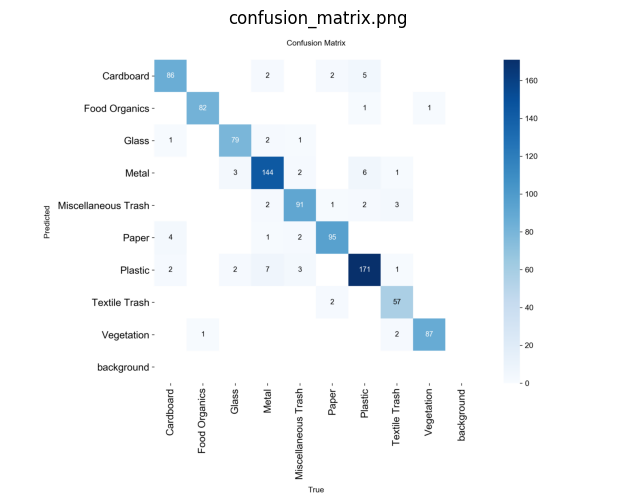

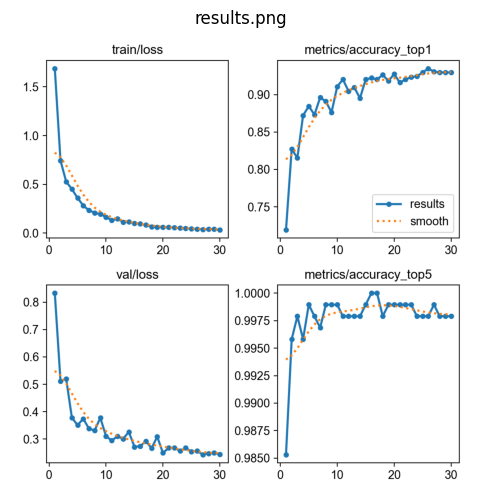

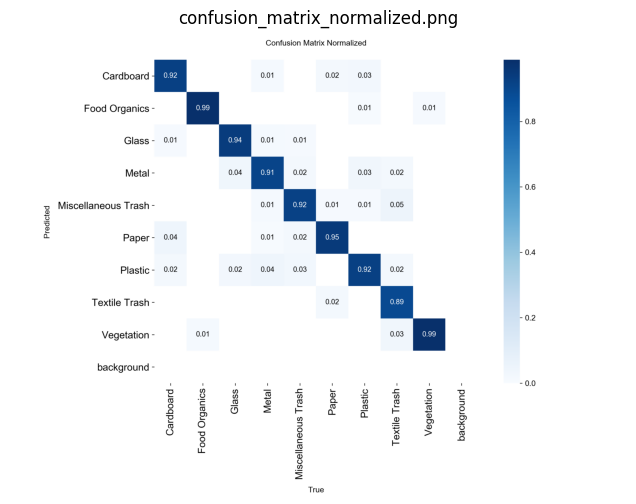

In [27]:
from PIL import Image
import matplotlib.pyplot as plt
import os

folder = "/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2"

for file in os.listdir(folder):
    if file.endswith(".png"):
        img = Image.open(os.path.join(folder, file))
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(file)


In [28]:
###- Display accuracy curve
img = Image.open("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/accuracy.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Accuracy Curve")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/accuracy.png'

In [29]:
### — Display loss curve
img = Image.open("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/loss.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Loss Curve")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/loss.png'

Text(0.5, 1.0, 'Confusion Matrix Normalized')

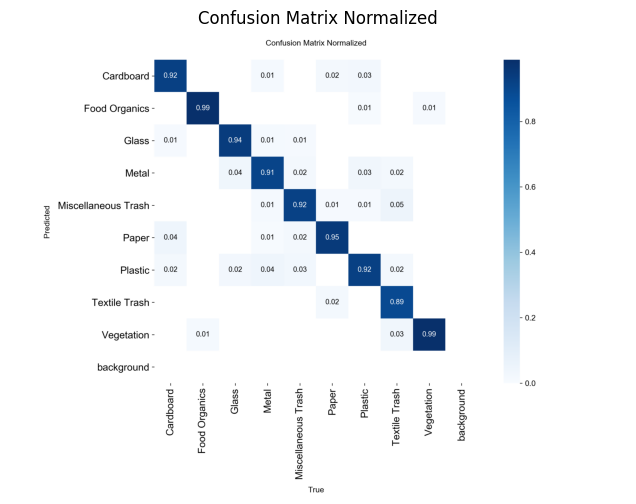

In [30]:
### — Display confusion matrix normalized
img = Image.open("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/confusion_matrix_normalized.png")
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix Normalized")

In [31]:
### — Read the numeric metrics (optional)
import pandas as pd

df = pd.read_csv("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/results.csv")
df.tail()


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
25,26,873.212,0.04250,0.93501,0.99790,0.25693,0.000135,0.000135,0.000135
26,27,909.095,0.03716,0.93082,0.99895,0.24349,0.000109,0.000109,0.000109
27,28,944.228,0.03915,0.92977,0.99790,0.24781,0.000084,0.000084,0.000084
28,29,982.937,0.04087,0.92977,0.99790,0.25002,0.000058,0.000058,0.000058
29,30,1019.530,0.03232,0.92977,0.99790,0.24366,0.000033,0.000033,0.000033


In [32]:
### Export Model to CoreML
from ultralytics import YOLO

model = YOLO("/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.pt")
model.export(format="coreml")


Ultralytics 8.4.41 🚀 Python-3.10.20 torch-2.11.0 CPU (Apple M5)
YOLOv8s-cls summary (fused): 30 layers, 5,086,729 parameters, 0 gradients, 12.5 GFLOPs

PyTorch: starting from '/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 9) (9.8 MB)
requirements: Ultralytics requirement ['coremltools>=9.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.8 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 22.4 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [coremltools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [coremltools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [coremltools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [coremltools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [coremltools]


requirements: AutoUpdate success ✅ 1.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Running MIL default pipeline:   0%|                                                         | 0/95 [00:00<?, ? passes/s]/opt/anaconda3/envs/yolo/lib/python3.10/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:273: UserWarning: Output, '379', of the source model, has been renamed to 'var_379' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
Running MIL backend_mlprogram pipeline: 100%|█████████████████████████████████████| 12/12 [00:00<00:00, 835.44 passes/s]


CoreML: export success ✅ 4.1s, saved as '/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.mlpackage' (9.8 MB)

Export complete (4.1s)
Results saved to /Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights
Predict:         yolo predict task=classify model=/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.mlpackage imgsz=224 
Validate:        yolo val task=classify model=/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.mlpackage imgsz=224 data=/Users/car/CSUChico/CSCI611/yolov8/realwaste-yolo/dataset  
Visualize:       https://netron.app


PosixPath('/Users/car/CSUChico/CSCI611/yolov8/runs/classify/train-2/weights/best.mlpackage')